# PERCOBAAN 5 : RESIZE + GRAYSCALE + MEDIAN + SOBEL + THRESHOLDING

Percobaan ini bertujuan untuk melakukan preprocessing citra menggunakan beberapa tahapan, yaitu resize, konversi grayscale, median filtering, deteksi tepi Sobel, dan thresholding. Hasil preprocessing kemudian diekstraksi menggunakan fitur GLCM dan digunakan sebagai masukan pada algoritma klasifikasi Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

## IMPORT LIBRARY

Tahap ini digunakan untuk mengimpor seluruh library yang diperlukan selama proses penelitian, mulai dari pengolahan citra, ekstraksi fitur, visualisasi data, hingga proses klasifikasi dan evaluasi model.

In [13]:
# Import library yang dibutuhkan
import os
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import entropy
from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

## LOAD DATASET

Dataset citra dibaca dari folder dataset yang telah disiapkan. Setiap gambar akan dimasukkan ke dalam variabel data beserta label kelasnya sehingga dapat digunakan pada proses preprocessing dan klasifikasi.

In [6]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset"

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

print("Folder dataset:", DATASET_DIR.resolve())

Folder dataset: D:\Praktikum PCD\Project-PCD-Kelompok-16\dataset


In [7]:
data = []
labels = []
file_name = []

for class_folder in sorted(DATASET_DIR.iterdir()):
    if not class_folder.is_dir():
        continue

    label = class_folder.name
    image_files = [
        file for file in sorted(class_folder.iterdir())
        if file.suffix.lower() in VALID_EXTENSIONS
    ]

    print(f"{label}: {len(image_files)} gambar")

    for image_path in image_files:
        image = cv.imread(str(image_path))

        if image is None:
            print("Gagal membaca gambar:", image_path)
            continue

        data.append(image.astype(np.uint8))
        labels.append(label)
        file_name.append(image_path.name)

data = np.array(data, dtype=object)
labels = np.array(labels)
file_name = np.array(file_name)

print("\nTotal data:", len(data))
print(pd.Series(labels).value_counts())

catterpillar: 70 gambar
snail: 70 gambar

Total data: 140
catterpillar    70
snail           70
Name: count, dtype: int64


## DATA AUGMENTATION

Data augmentation digunakan untuk menambah variasi data pelatihan dengan melakukan transformasi tertentu pada citra. Pada percobaan ini augmentation dapat diaktifkan atau dinonaktifkan sesuai kebutuhan eksperimen.

In [28]:
def augment_image(image):
    return []

In [29]:
USE_AUGMENTATION = False

data_used = list(data)
labels_used = list(labels)
file_name_used = list(file_name)

if USE_AUGMENTATION:
    for image, label, filename in zip(data, labels, file_name):
        for index, augmented_image in enumerate(augment_image(image), start=1):
            data_used.append(augmented_image.astype(np.uint8))
            labels_used.append(label)
            name, ext = os.path.splitext(filename)
            file_name_used.append(f"{name}_aug{index}{ext}")

data_used = np.array(data_used, dtype=object)
labels_used = np.array(labels_used)
file_name_used = np.array(file_name_used)

print("Data sebelum augmentasi:", len(data))
print("Data yang digunakan:", len(data_used))

Data sebelum augmentasi: 140
Data yang digunakan: 140


## DATA PREPARATION

Tahap data preparation bertujuan mempersiapkan citra sebelum dilakukan ekstraksi fitur.

### DEFINE PREPROCESSING FUNCTION

Fungsi preprocessing yang digunakan pada percobaan ini terdiri dari:

1. Resize untuk menyeragamkan ukuran citra.
2. Grayscale untuk mengubah citra RGB menjadi citra keabuan.
3. Median Filter untuk mengurangi noise tanpa merusak tepi objek.
4. Sobel untuk mendeteksi tepi objek berdasarkan perubahan intensitas piksel.
5. Thresholding untuk mengubah citra menjadi citra biner sehingga objek lebih mudah dipisahkan dari latar belakang.

In [30]:
TARGET_SIZE = (384, 256)


def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)

    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    return gray.astype(np.uint8)


def filter(img, size, mode):

    height, width = img.shape
    pad = size // 2

    padded = np.pad(img, pad, mode="edge")

    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:

        case "median":
            for i in range(height):
                for j in range(width):

                    region = padded[i:i+size, j:j+size]

                    canvas[i, j] = np.median(region)

    return canvas


def sobel(img):

    # Kernel Sobel
    gx_kernel = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ])

    gy_kernel = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ])

    height, width = img.shape

    padded = np.pad(img, 1, mode='edge')

    gx = np.zeros_like(img, dtype=np.float32)
    gy = np.zeros_like(img, dtype=np.float32)

    # Konvolusi Sobel
    for i in range(height):
        for j in range(width):

            region = padded[i:i+3, j:j+3]

            gx[i, j] = np.sum(region * gx_kernel)
            gy[i, j] = np.sum(region * gy_kernel)

    # Magnitude gradient
    sobel_result = np.sqrt(gx**2 + gy**2)

    # Normalisasi ke 0-255
    sobel_result = np.clip(sobel_result, 0, 255)

    return sobel_result.astype(np.uint8)

def thresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)

    for i in range(baris):
        for j in range(kolom):
            if(img[i,j] > batas):
                canvas[i,j] = 255
            elif(img[i,j] <= batas):
                canvas[i,j] = 0

    return canvas

def prepo5(image):

    # Resize + Grayscale
    gray = resize_grayscale(image)

    # Median Filter
    median = filter(gray, 3, "median")

    # Sobel
    sobel_img = sobel(median)

    # Thresholding
    threshold = thresholding(sobel_img, 33)

    return threshold

### PREPROCESSING DATA

Pada tahap ini seluruh citra pada dataset diproses menggunakan fungsi preprocessing yang telah dibuat. Hasil preprocessing akan disimpan untuk digunakan pada tahap ekstraksi fitur.

In [31]:
dataPreprocessed = []

for image in data_used:
    dataPreprocessed.append(prepo5(image))

dataPreprocessed = np.stack(dataPreprocessed).astype(np.uint8)

print("Jumlah data setelah preprocessing:", len(dataPreprocessed))
print("Ukuran target (width, height):", TARGET_SIZE)
print("Shape contoh gambar:", dataPreprocessed[0].shape)
print("Tipe data gambar:", dataPreprocessed.dtype)

Jumlah data setelah preprocessing: 140
Ukuran target (width, height): (384, 256)
Shape contoh gambar: (256, 384)
Tipe data gambar: uint8


### MENAMPILKAN HASIL

Bagian ini digunakan untuk menampilkan beberapa contoh citra hasil preprocessing sehingga perubahan yang terjadi setelah proses resize, grayscale, median filtering, Sobel, dan thresholding dapat diamati secara visual.

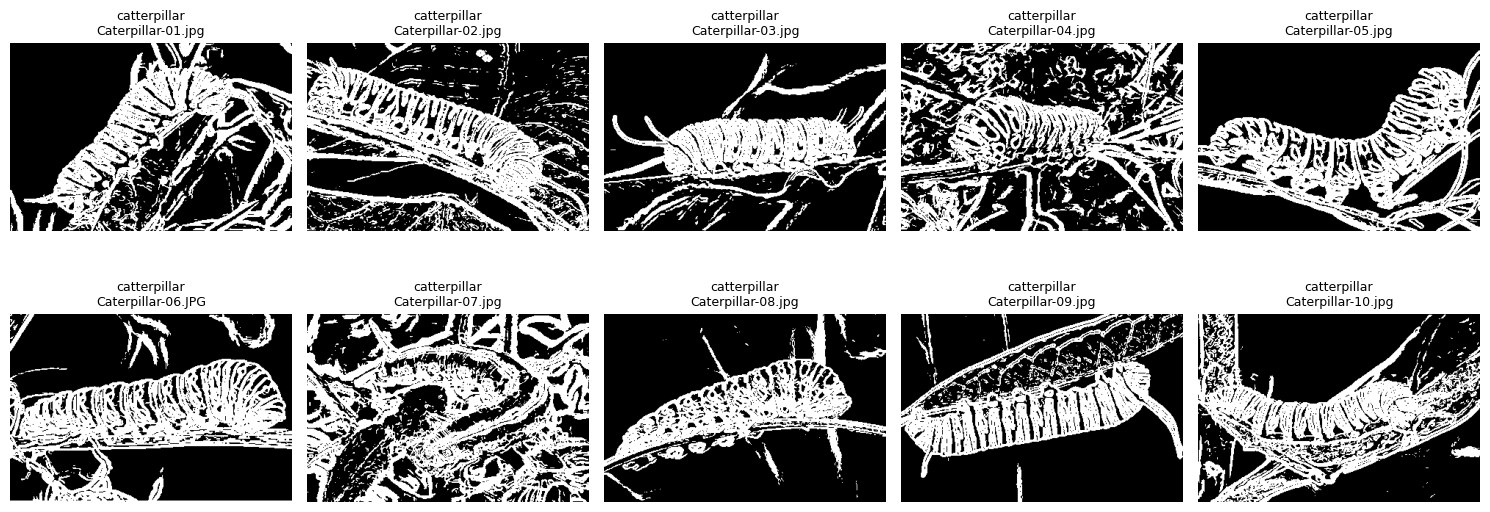

In [32]:
# Menampilkan 10 contoh gambar setelah preprocessing grayscale + resize + median + sobel + thresholding
jumlah_gambar = min(10, len(dataPreprocessed))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.axis("off")

    if i < jumlah_gambar:
        ax.imshow(dataPreprocessed[i], cmap="gray")
        ax.set_title(f"{labels_used[i]}\n{file_name_used[i]}", fontsize=9)

plt.tight_layout()
plt.show()

## FEATURE EXTRACTION

Setelah preprocessing selesai dilakukan, citra diekstraksi menggunakan metode Gray Level Co-occurrence Matrix (GLCM). Metode ini digunakan untuk memperoleh karakteristik tekstur citra yang akan digunakan sebagai fitur pada proses klasifikasi.

In [33]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Derajat harus salah satu dari: 0, 45, 90, 135.")

    return graycomatrix(
        image,
        distances=[1],
        angles=angles,
        levels=256,
        symmetric=True,
        normed=True,
    )


In [34]:
def safe_value(value):
    value = float(value)
    if np.isnan(value) or np.isinf(value):
        return 0.0
    return value

In [35]:
def correlation(matriks):
    return safe_value(graycoprops(matriks, "correlation")[0, 0])


def dissimilarity(matriks):
    return safe_value(graycoprops(matriks, "dissimilarity")[0, 0])


def homogenity(matriks):
    return safe_value(graycoprops(matriks, "homogeneity")[0, 0])


def contrast(matriks):
    return safe_value(graycoprops(matriks, "contrast")[0, 0])


def ASM(matriks):
    return safe_value(graycoprops(matriks, "ASM")[0, 0])


def energy(matriks):
    return safe_value(graycoprops(matriks, "energy")[0, 0])


def entropyGlcm(matriks):
    return safe_value(entropy(matriks.ravel()))

In [36]:
def extract_glcm_features(image):
    if image.ndim == 3:
        image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    image = image.astype(np.uint8)
    features = {}

    for derajat in [0, 45, 90, 135]:
        matriks = glcm(image, derajat)
        features[f"Contrast{derajat}"] = contrast(matriks)
        features[f"Homogeneity{derajat}"] = homogenity(matriks)
        features[f"Dissimilarity{derajat}"] = dissimilarity(matriks)
        features[f"Entropy{derajat}"] = entropyGlcm(matriks)
        features[f"ASM{derajat}"] = ASM(matriks)
        features[f"Energy{derajat}"] = energy(matriks)
        features[f"Correlation{derajat}"] = correlation(matriks)
    return features


In [37]:
rows = []

for image, label, filename in zip(dataPreprocessed, labels_used, file_name_used):
    row = {
        "Filename": filename,
        "Label": label,
    }
    row.update(extract_glcm_features(image))
    rows.append(row)

hasilEkstrak = pd.DataFrame(rows)
hasilEkstrak.head()

,Filename,Label,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Contrast45,...,ASM90,Energy90,Correlation90,Contrast135,Homogeneity135,Dissimilarity135,Entropy135,ASM135,Energy135,Correlation135
0,Caterpillar-01.jpg,catterpillar,4962.692508,0.923681,19.461539,0.903945,0.482734,0.694791,0.829175,6946.919060,...,0.479395,0.692384,0.820153,6380.992167,0.901870,25.023499,0.953992,0.464497,0.681540,0.780467
1,Caterpillar-02.jpg,catterpillar,6206.184216,0.904558,24.337977,0.974202,0.443945,0.666292,0.796809,9676.018277,...,0.418884,0.647213,0.728697,9496.253264,0.853962,37.240209,1.073390,0.405210,0.636561,0.689328
2,Caterpillar-03.jpg,catterpillar,3373.675904,0.948118,13.230102,0.773029,0.563274,0.750516,0.866121,5532.767624,...,0.552500,0.743303,0.836622,4514.099217,0.930580,17.702350,0.819658,0.546941,0.739554,0.821291
3,Caterpillar-04.jpg,catterpillar,7754.082694,0.880754,30.408167,1.044064,0.407678,0.638497,0.755286,11448.368146,...,0.395423,0.628827,0.722095,10958.342037,0.831478,42.973890,1.131582,0.372359,0.610212,0.654319
4,Caterpillar-05.jpg,catterpillar,3954.635230,0.939184,15.508373,0.875621,0.486042,0.697167,0.866874,5966.866841,...,0.469530,0.685222,0.826013,6367.010444,0.902085,24.968668,0.965624,0.454201,0.673944,0.785961


### HASIL EKSTRAKSI FITUR

Bagian ini menampilkan hasil ekstraksi fitur GLCM untuk setiap citra. Nilai-nilai fitur tersebut akan menjadi representasi numerik yang digunakan sebagai masukan model klasifikasi.

In [38]:
print("Jumlah data hasil ekstraksi:", len(hasilEkstrak))
hasilEkstrak

Jumlah data hasil ekstraksi: 140


,Filename,Label,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Contrast45,...,ASM90,Energy90,Correlation90,Contrast135,Homogeneity135,Dissimilarity135,Entropy135,ASM135,Energy135,Correlation135
0,Caterpillar-01.jpg,catterpillar,4962.692508,0.923681,19.461539,0.903945,0.482734,0.694791,0.829175,6946.919060,...,0.479395,0.692384,0.820153,6380.992167,0.901870,25.023499,0.953992,0.464497,0.681540,0.780467
1,Caterpillar-02.jpg,catterpillar,6206.184216,0.904558,24.337977,0.974202,0.443945,0.666292,0.796809,9676.018277,...,0.418884,0.647213,0.728697,9496.253264,0.853962,37.240209,1.073390,0.405210,0.636561,0.689328
2,Caterpillar-03.jpg,catterpillar,3373.675904,0.948118,13.230102,0.773029,0.563274,0.750516,0.866121,5532.767624,...,0.552500,0.743303,0.836622,4514.099217,0.930580,17.702350,0.819658,0.546941,0.739554,0.821291
3,Caterpillar-04.jpg,catterpillar,7754.082694,0.880754,30.408167,1.044064,0.407678,0.638497,0.755286,11448.368146,...,0.395423,0.628827,0.722095,10958.342037,0.831478,42.973890,1.131582,0.372359,0.610212,0.654319
4,Caterpillar-05.jpg,catterpillar,3954.635230,0.939184,15.508373,0.875621,0.486042,0.697167,0.866874,5966.866841,...,0.469530,0.685222,0.826013,6367.010444,0.902085,24.968668,0.965624,0.454201,0.673944,0.785961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,snail (95).jpg,snail,9591.797640,0.852493,37.614893,1.052654,0.423260,0.650584,0.672921,13507.676240,...,0.400524,0.632870,0.597018,13756.684073,0.788443,53.947781,1.144774,0.382567,0.618520,0.530525
136,snail (96).jpg,snail,5966.770612,0.908240,23.399100,0.992696,0.423041,0.650416,0.814105,11229.321149,...,0.375825,0.613046,0.688056,11234.647520,0.827228,44.057441,1.146043,0.363149,0.602618,0.650203
137,snail (97).jpg,snail,5922.336509,0.908924,23.224849,0.926329,0.480778,0.693381,0.791316,8386.370757,...,0.477900,0.691303,0.783395,7468.903394,0.885140,29.289817,0.976598,0.461242,0.679148,0.737212
138,snail (98).jpg,snail,10188.010464,0.843324,39.952982,1.020641,0.453932,0.673745,0.621493,14234.725849,...,0.439323,0.662815,0.570604,14342.584856,0.779433,56.245431,1.105234,0.413591,0.643111,0.467851


### SELEKSI FITUR

Seleksi fitur dilakukan untuk melihat hubungan antar fitur yang dihasilkan. Analisis korelasi digunakan untuk mengetahui apakah terdapat fitur yang memiliki hubungan sangat kuat sehingga dapat mempengaruhi performa model.

Jumlah fitur awal: 28
Jumlah fitur setelah selection: 5
Fitur yang digunakan:
['Contrast0', 'Entropy0', 'Correlation0', 'Contrast45', 'Correlation45']


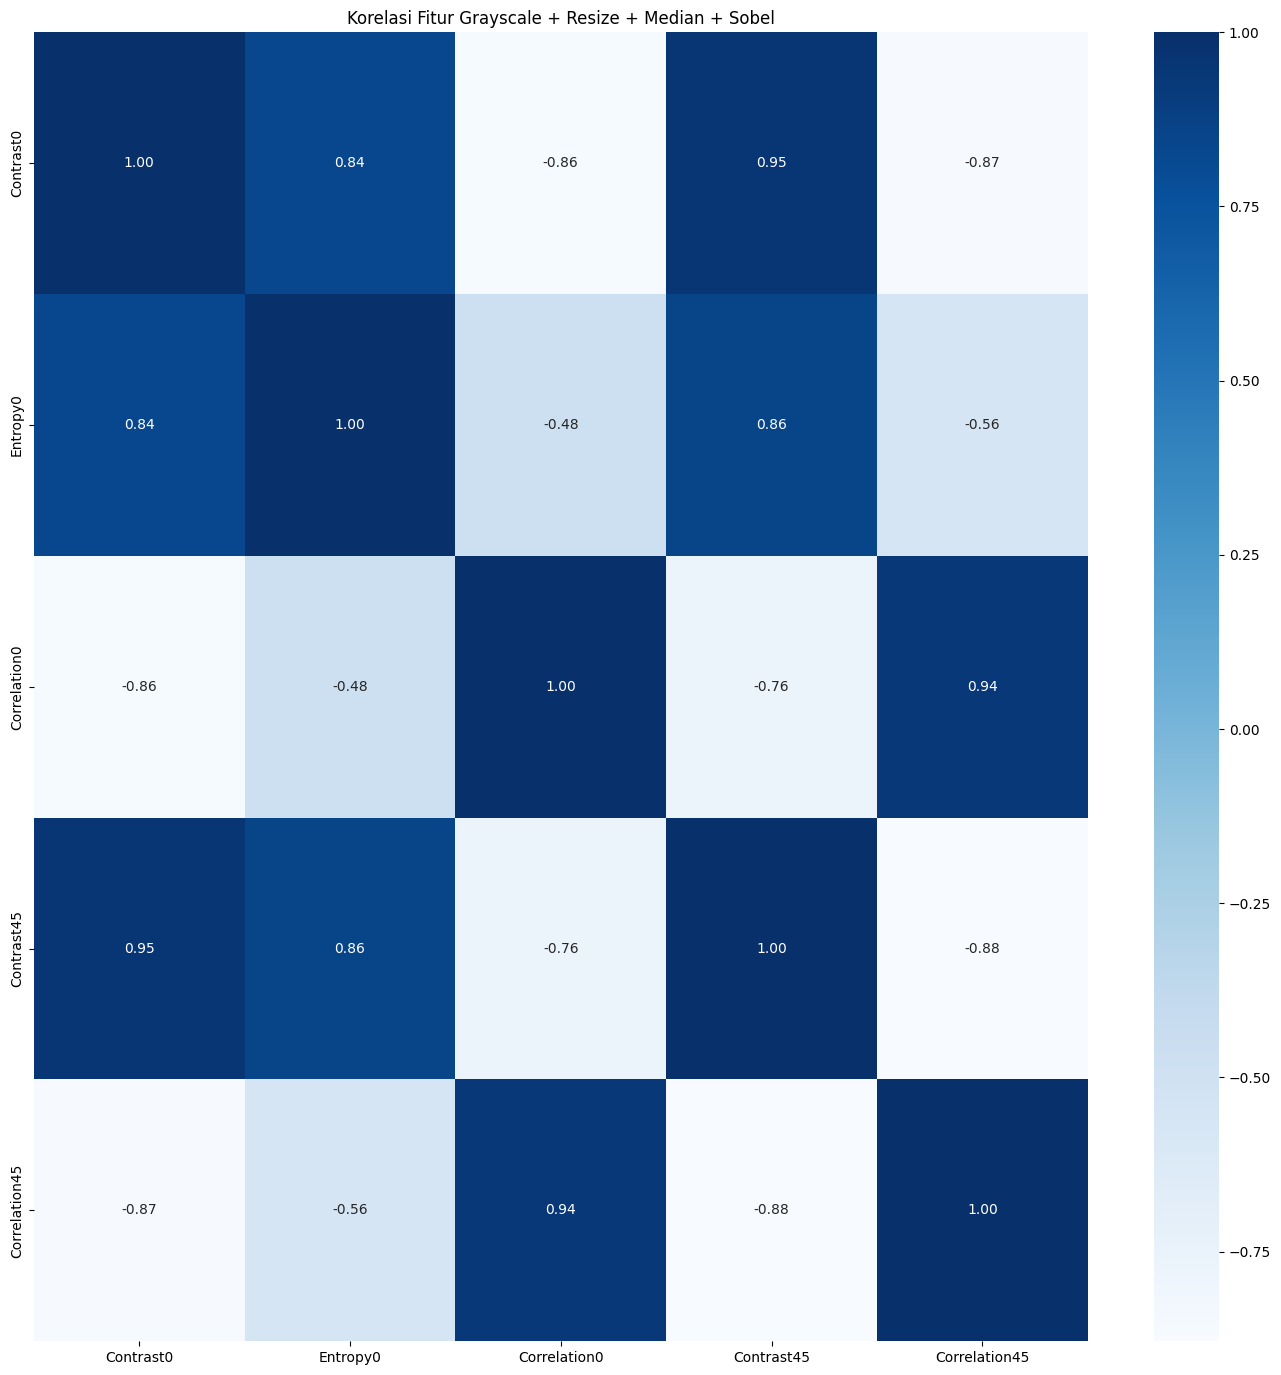

In [39]:
# Menghitung korelasi antar fitur numerik
feature_data = hasilEkstrak.drop(columns=["Label", "Filename"])
feature_data = feature_data.select_dtypes(include=[np.number])

correlation_matrix = feature_data.corr().abs()

# Menyaring fitur yang memiliki korelasi absolut lebih dari threshold
threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = feature_data.columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak["Label"]

print("Jumlah fitur awal:", feature_data.shape[1])
print("Jumlah fitur setelah selection:", len(select))
print("Fitur yang digunakan:")
print(list(select))

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Korelasi Fitur Grayscale + Resize + Median + Sobel")
plt.show()

## SPLITTING DATA

Dataset dibagi menjadi data latih (training set) dan data uji (testing set). Data latih digunakan untuk membangun model, sedangkan data uji digunakan untuk mengukur kemampuan model dalam melakukan prediksi terhadap data yang belum pernah dilihat sebelumnya.

In [40]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    x_new,
    y,
    test_size=0.2,
    random_state=45,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:")
print(y_train.value_counts())
print("y_test:")
print(y_test.value_counts())


X_train: (112, 5)
X_test: (28, 5)
y_train:
Label
snail           56
catterpillar    56
Name: count, dtype: int64
y_test:
Label
catterpillar    14
snail           14
Name: count, dtype: int64


## NORMALISASI FITUR

Normalisasi dilakukan untuk menyamakan skala seluruh fitur sehingga tidak ada fitur yang mendominasi proses pembelajaran model. Proses ini sangat penting terutama pada algoritma SVM dan KNN yang sensitif terhadap perbedaan skala data.

In [41]:
# normalisasi mean std
std_train = X_train.std().replace(0, 1)
X_test = (X_test - X_train.mean()) / std_train
X_train = (X_train - X_train.mean()) / std_train

X_train.head()

,Contrast0,Entropy0,Correlation0,Contrast45,Correlation45
83,0.107439,0.408565,0.084441,0.528668,-0.341279
95,-1.296571,-1.017883,1.194678,-1.282401,1.269502
45,1.169871,1.267615,-0.637504,0.896051,-0.461126
116,-0.782574,-0.995844,0.438316,-0.614841,0.234446
91,-0.675772,-0.630187,0.507248,-0.573650,0.412349


## MODELLING

Tahap modelling digunakan untuk membangun model klasifikasi berdasarkan fitur yang telah diekstraksi.

### DEFINE MODEL

Pada percobaan ini digunakan tiga algoritma klasifikasi, yaitu:

- Random Forest (RF)
- Support Vector Machine (SVM)
- K-Nearest Neighbor (KNN)

Ketiga model akan dibandingkan performanya untuk mengetahui algoritma yang paling sesuai terhadap dataset yang digunakan.

In [42]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel="rbf", random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

hasil_model = []

### TRAIN RANDOM FOREST CLASSIFIER

Random Forest merupakan metode ensemble yang membangun banyak decision tree dan menggabungkan hasil prediksinya. Model ini dilatih menggunakan data training dan kemudian dievaluasi menggunakan data testing.

In [43]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred_rf_train = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_rf_train)

print("\n------Testing Set------")
y_pred_rf_test = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf_test)

hasil_model.append({
    "Percobaan": "grayscale_resize_median_equ",
    "Model": "Random Forest",
    "Train Accuracy": accuracy_score(y_train, y_pred_rf_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_rf_test),
    "Precision": precision_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
})

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.96      0.96      0.96        56
       snail       0.96      0.96      0.96        56

    accuracy                           0.96       112
   macro avg       0.96      0.96      0.96       112
weighted avg       0.96      0.96      0.96       112

[[54  2]
 [ 2 54]]
Accuracy: 0.9642857142857143

------Testing Set------
              precision    recall  f1-score   support

catterpillar       0.59      0.71      0.65        14
       snail       0.64      0.50      0.56        14

    accuracy                           0.61        28
   macro avg       0.61      0.61      0.60        28
weighted avg       0.61      0.61      0.60        28

[[10  4]
 [ 7  7]]
Accuracy: 0.6071428571428571


### TRAIN SVM CLASSIFIER

Support Vector Machine (SVM) digunakan untuk mencari hyperplane terbaik yang mampu memisahkan kelas-kelas data secara optimal pada ruang fitur.

In [44]:
# Train SVM Classifier
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred_svm_train = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_svm_train)

print("\n------Testing Set------")
y_pred_svm_test = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm_test)

hasil_model.append({
    "Percobaan": "grayscale_resize_median_equ",
    "Model": "SVM",
    "Train Accuracy": accuracy_score(y_train, y_pred_svm_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_svm_test),
    "Precision": precision_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
})

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.68      0.79      0.73        56
       snail       0.74      0.62      0.68        56

    accuracy                           0.71       112
   macro avg       0.71      0.71      0.70       112
weighted avg       0.71      0.71      0.70       112

[[44 12]
 [21 35]]
Accuracy: 0.7053571428571429

------Testing Set------
              precision    recall  f1-score   support

catterpillar       0.65      0.93      0.76        14
       snail       0.88      0.50      0.64        14

    accuracy                           0.71        28
   macro avg       0.76      0.71      0.70        28
weighted avg       0.76      0.71      0.70        28

[[13  1]
 [ 7  7]]
Accuracy: 0.7142857142857143


### TRAIN KNN CLASSIFIER

K-Nearest Neighbor (KNN) melakukan klasifikasi berdasarkan kedekatan suatu data terhadap sejumlah tetangga terdekat pada ruang fitur.

In [45]:
# Train KNN Classifier
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred_knn_train = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_knn_train)

print("\n------Testing Set------")
y_pred_knn_test = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn_test)

hasil_model.append({
    "Percobaan": "grayscale_resize_median_equ",
    "Model": "KNN",
    "Train Accuracy": accuracy_score(y_train, y_pred_knn_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_knn_test),
    "Precision": precision_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
})

df_hasil_model = pd.DataFrame(hasil_model)
print("Ringkasan hasil klasifikasi:")
df_hasil_model

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.71      0.70      0.70        56
       snail       0.70      0.71      0.71        56

    accuracy                           0.71       112
   macro avg       0.71      0.71      0.71       112
weighted avg       0.71      0.71      0.71       112

[[39 17]
 [16 40]]
Accuracy: 0.7053571428571429

------Testing Set------
              precision    recall  f1-score   support

catterpillar       0.76      0.93      0.84        14
       snail       0.91      0.71      0.80        14

    accuracy                           0.82        28
   macro avg       0.84      0.82      0.82        28
weighted avg       0.84      0.82      0.82        28

[[13  1]
 [ 4 10]]
Accuracy: 0.8214285714285714
Ringkasan hasil klasifikasi:


,Percobaan,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,grayscale_resize_median_equ,Random Forest,0.964286,0.607143,0.612299,0.607143,0.602581
1,grayscale_resize_median_equ,SVM,0.705357,0.714286,0.762500,0.714286,0.700535
2,grayscale_resize_median_equ,KNN,0.705357,0.821429,0.836898,0.821429,0.819355


## EVALUATION WITH CONFUSION MATRIX

Evaluasi dilakukan menggunakan confusion matrix untuk melihat kemampuan model dalam mengklasifikasikan setiap kelas. Selain itu digunakan metrik accuracy, precision, recall, dan F1-score untuk mengukur performa masing-masing algoritma klasifikasi.

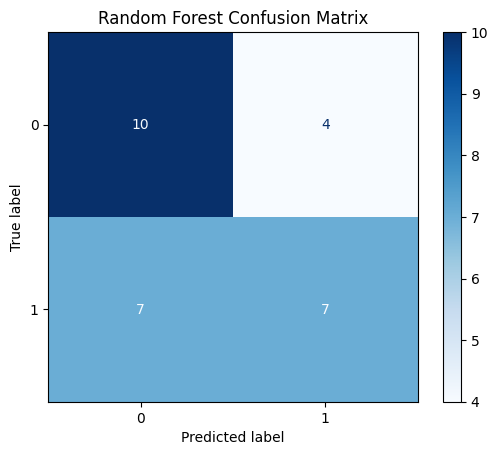

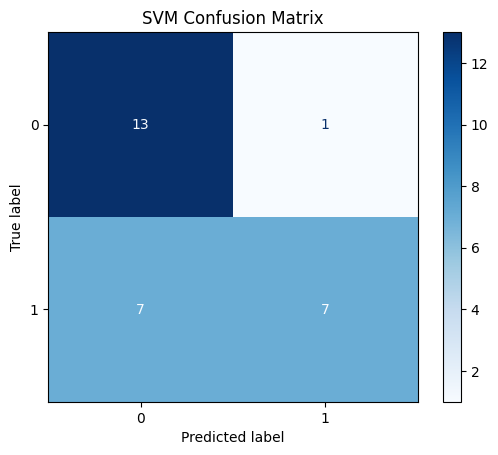

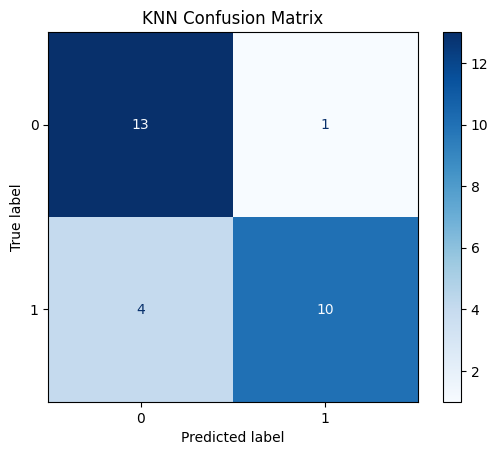

In [46]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()


plot_confusion_matrix(y_test, y_pred_rf_test, "Random Forest Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_svm_test, "SVM Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_knn_test, "KNN Confusion Matrix")